# Maze representations

This tutorial introduces the `networkx`-backed representations of each session's maze structure.

Mazes are stored on disk as a human-readable edge list in [`../data/experiment_info/maze_configs.json`](../data/experiment_info/maze_configs.json) — each entry is a list of strings like `"A1-A2"` naming two adjacent towers on the 7×7 grid.

The `GridMaze.maze.representations` module turns those edge lists into three graph views:

- **`simple_maze`** — towers as nodes, bridges as edges. The primary form.
- **`extended_simple_maze`** — towers **and** bridges as nodes.
- **`skeleton_maze`** — 5 nodes per tower, 3 per bridge, for sub-tower spatial resolution.

In [1]:
# imports
import json
import networkx as nx
from pathlib import Path
from matplotlib import pyplot as plt
from GridMaze.maze import representations as mr

## Loading a maze structure

Load `maze_configs.json` and pick one maze's edge list to work with.

In [2]:
with open(Path("../data/experiment_info/maze_configs.json")) as f:
    MAZE_CONFIGS = json.load(f)

maze_1_structure = MAZE_CONFIGS["maze_1"]["structure"]
print(f"First five edges: {maze_1_structure[:5]}")
print(f"Total edges: {len(maze_1_structure)}")

First five edges: ['A1-A2', 'A3-A4', 'A4-A5', 'A5-A6', 'A6-A7']
Total edges: 52


## `simple_maze` — towers as nodes, bridges as edges

`mr.simple_maze(...)` turns the edge list into a `networkx` graph built on top of `nx.grid_2d_graph`. Nodes are `(row, col)` tuples on the 7×7 grid, with two attributes attached:

- `label` — the human-readable name, e.g. `"A1"`.
- `position` — the `(x, y)` position in metres, useful as the layout for plotting.

In [3]:
simple_maze = mr.simple_maze(maze_1_structure)

print(f"Nodes: {list(simple_maze.nodes())[:5]} …")
print(f"Edges: {list(simple_maze.edges())[:3]} …")

coord2label = nx.get_node_attributes(simple_maze, "label")
coord2pos = nx.get_node_attributes(simple_maze, "position")
print(f"Label of (0, 0): {coord2label[(0, 0)]}")
print(f"Position of (0, 0): {coord2pos[(0, 0)]}")

Nodes: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4)] …
Edges: [((0, 0), (0, np.int64(1))), ((0, 1), (1, np.int64(1))), ((0, 2), (0, np.int64(3)))] …
Label of (0, 0): A1
Position of (0, 0): (0.15, np.float64(0.15))


Plot it directly with `networkx`, using each node's `position` attribute for the layout:

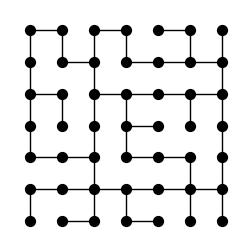

In [4]:
f, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.axis("off")
nx.draw_networkx(simple_maze, pos=coord2pos, with_labels=False, node_size=50, node_color="k", ax=ax)

## `extended_simple_maze` — towers **and** bridges as nodes

Built from a `simple_maze` by promoting each edge to a node. Useful when an analysis needs to assign a value to bridges as well as towers (e.g. occupancy or visit counts along the path between two towers).

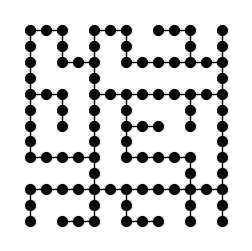

In [5]:
extended_maze = mr.get_extended_simple_maze(simple_maze)
ex_coord2pos = nx.get_node_attributes(extended_maze, "position")

f, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.axis("off")
nx.draw_networkx(extended_maze, pos=ex_coord2pos, with_labels=False, node_size=50, node_color="k", ax=ax)

## `skeleton_maze` — sub-tower spatial resolution

5 nodes per tower and 3 nodes per bridge. Useful when an analysis needs finer spatial bins than one-per-tower — e.g. for binning trajectories or aligning neural activity to position along a bridge.

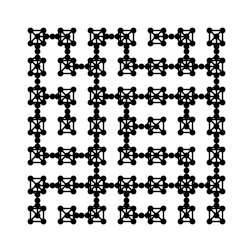

In [6]:
skeleton_maze = mr.skeleton_maze(maze_1_structure)
sk_coord2pos = nx.get_node_attributes(skeleton_maze, "position")

f, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.axis("off")
nx.draw(skeleton_maze, pos=sk_coord2pos, with_labels=False, node_size=10, node_color="k", ax=ax)